# Let's teach a tiny Transformer to execute a circuit

We're going to sample 4-bit reversible circuits, tokenize the **trace** (not English CoT), and train two copies of the same one-layer net: one on the short answer, one on gate→state→gate→state…

The weights-as-rules models live in `handcoded.models`. We import them. We do not paste 800 lines of `nn.Module` into this notebook.

Kernel = this repo's Python. Run from the repo root (or one folder down; we fix `sys.path`). Prefer GPU 2 on the shared box.

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "handcoded").is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from handcoded.plotting import apply_style

apply_style()

SMOKE = False  # False → paper-ish sizes (or load configs/handcoded.yaml)
n_bits = 4
depth = 4
train_size = 256 if SMOKE else 20_000
test_size = 64 if SMOKE else 1_000
steps = 40 if SMOKE else 10_000
batch_size = 32 if SMOKE else 128
lr = 2e-3
d_model, n_heads, d_ff = (64, 4, 128) if SMOKE else (96, 4, 192)
data_seed, test_seed, model_seed, batch_seed = 123, 9000, 42, 2026

if torch.cuda.is_available() and torch.cuda.device_count() > 2:
    device = "cuda:2"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(f"device={device}  smoke={SMOKE}  steps={steps}  n_train={train_size}")

device=cuda:2  smoke=False  steps=10000  n_train=20000


## 1. A circuit is just bits and gates

Four bits. Flip / CNOT / swap / Toffoli. Index 0 is the **leftmost** bit.
Let's sample a few and print the gold states. `phi` is the labeler — the net never calls it at inference.

In [2]:
from handcoded.gates import make_circuits, make_gate_names, phi, state_text

print("n_gates", len(make_gate_names(n_bits)), "e.g.", make_gate_names(n_bits)[:6], "...")

circuits = make_circuits(3, seed=0, depth=depth, n_bits=n_bits)
for c in circuits:
    start_bits = state_text([int(b) for b in f"{c.start:04b}"])
    path = [f"{s:04b}" for s in c.states]
    print(f"start={start_bits}  gates={list(c.gates)}  states={path}  answer={c.answer:04b}")
    print("  phi(start, g0) == first state?", phi(c.start, c.gates[0]) == c.states[0])

n_gates 52 e.g. ['x0', 'x1', 'x2', 'x3', 'c01', 'c02'] ...
start=1100  gates=['t012', 't213', 'c13', 'c02']  states=['1110', '1111', '1110', '1100']  answer=1100
  phi(start, g0) == first state? True
start=1000  gates=['c20', 'x2', 't012', 's12']  states=['1000', '1010', '1010', '1100']  answer=1100
  phi(start, g0) == first state? True
start=1111  gates=['t203', 'x3', 'x3', 's12']  states=['1110', '1111', '1110', '1110']  answer=1110
  phi(start, g0) == first state? True


## 2. Semantic tokens (one state = one token)

Not the character GPT in `src.models.gpt`. `S1000` is a single id. Prompt is always start + gates + `<SEP>`. Then either a short **outcome** (`<COLON>` answer `<EOS>`) or a **process** trace.

In [3]:
from handcoded.tokenizer import make_tokenizer
from handcoded.data import encode_dataset

tok = make_tokenizer(n_bits)
ex = circuits[0]
prompt_ids = tok.prompt(ex)
out_ids = tok.continuation(ex, "outcome")
proc_ids = tok.continuation(ex, "process")

print("vocab", len(tok.tokens), "n_states", tok.n_states)
print("prompt ids ", prompt_ids)
print("prompt     ", tok.decode(prompt_ids))
print("outcome ids", out_ids)
print("outcome    ", tok.decode(out_ids))
print("process ids", proc_ids)
print("process    ", tok.decode(proc_ids))

batch = encode_dataset(circuits, tok, "process").to(device)
print("inputs  shape", tuple(batch.inputs.shape), batch.inputs.dtype)
print("targets shape", tuple(batch.targets.shape))
print("row0 inputs ", batch.inputs[0].tolist())
print("row0 targets", batch.targets[0].tolist())  # -100 on prompt positions

vocab 72 n_states 16
prompt ids  [12, 44, 59, 25, 21, 68]
prompt      S1100 t012 t213 c13 c02 <SEP>
outcome ids [69, 12, 70]
outcome     <COLON> S1100 <EOS>
process ids [44, 14, 59, 15, 25, 14, 21, 12, 69, 12, 70]
process     t012 S1110 t213 S1111 c13 S1110 c02 S1100 <COLON> S1100 <EOS>
inputs  shape (3, 16) torch.int64
targets shape (3, 16)
row0 inputs  [12, 44, 59, 25, 21, 68, 44, 14, 59, 15, 25, 14, 21, 12, 69, 12]
row0 targets [-100, -100, -100, -100, -100, 44, 14, 59, 15, 25, 14, 21, 12, 69, 12, 70]


## 3. Peek at the learned net: causal mask + logits

`LearnedOneLayerTransformer`: one causal attention, 4 heads, residual, ReLU MLP, **no LayerNorm**. Let's build one and print shapes.

In [4]:
from handcoded.models import LearnedOneLayerTransformer, build_random_learned_model

model = build_random_learned_model(
    tok, depth, seed=model_seed, d_model=d_model, n_heads=n_heads, d_ff=d_ff, device=device,
)
assert isinstance(model, LearnedOneLayerTransformer)
x = batch.inputs[:2]
logits, attn = model(x, return_attention=True)
print("x      ", tuple(x.shape))
print("logits ", tuple(logits.shape))  # (B, T, vocab)
print("attn   ", tuple(attn.shape))    # (B, heads, T, T)
T = x.shape[1]
causal = torch.ones(T, T, dtype=torch.bool).triu(1)
print("causal mask (1 = blocked), 8x8\n", causal[:8, :8].int().cpu().numpy())
print("attn head0, 6x6\n", attn[0, 0, :6, :6].detach().cpu().numpy().round(3))

x       (2, 16)
logits  (2, 16, 72)
attn    (2, 4, 16, 16)
causal mask (1 = blocked), 8x8
 [[0 1 1 1 1 1 1 1]
 [0 0 1 1 1 1 1 1]
 [0 0 0 1 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0]]
attn head0, 6x6
 [[1.    0.    0.    0.    0.    0.   ]
 [0.747 0.253 0.    0.    0.    0.   ]
 [0.169 0.285 0.546 0.    0.    0.   ]
 [0.387 0.182 0.342 0.089 0.    0.   ]
 [0.394 0.096 0.207 0.047 0.255 0.   ]
 [0.127 0.162 0.198 0.027 0.069 0.416]]


## 4. Fixed executors (weights = the rule)

We also have a process Transformer and an outcome Transformer whose buffers *are* φ. No training. If free-run isn't exact, we have a bug — in the package, not in a pasted class.

In [5]:
from handcoded.models import HandcodedOutcomeTransformer, HandcodedProcessTransformer
from handcoded.generate import generate
from handcoded.eval import make_generation_evaluation, free_run_metrics

probe = make_circuits(8, seed=1, depth=depth, n_bits=n_bits)
ev = make_generation_evaluation(probe, tok, device)
fixed_p = HandcodedProcessTransformer(tok, depth).to(device).eval()
fixed_o = HandcodedOutcomeTransformer(tok, depth).to(device).eval()
print("process", free_run_metrics(fixed_p, ev, tok, "process"))
print("outcome", free_run_metrics(fixed_o, ev, tok, "outcome"))

prompt = torch.tensor([tok.prompt(ex)], device=device)
gen = generate(fixed_p, prompt, max_new_tokens=2 * depth + 3, eos_id=tok.eos)
print("gold process ", tok.decode(tok.prompt(ex) + tok.continuation(ex, "process")))
print("generated    ", tok.decode(gen[0].tolist()))

process {'exact_continuation': 1.0, 'final_answer': 1.0}
outcome {'exact_continuation': 1.0, 'final_answer': 1.0}
gold process  S1100 t012 t213 c13 c02 <SEP> t012 S1110 t213 S1111 c13 S1110 c02 S1100 <COLON> S1100 <EOS>
generated     S1100 t012 t213 c13 c02 <SEP> t012 S1110 t213 S1111 c13 S1110 c02 S1100 <COLON> S1100 <EOS>


## 5. One train step, written out

`train_step` in `handcoded.train` is these five lines. Let's do them on a tiny batch and watch the number move.

In [6]:
from handcoded.data import language_model_loss

tiny = encode_dataset(circuits, tok, "process").to(device)
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0)
print("loss before", language_model_loss(model, tiny).item())

model.train()
opt.zero_grad(set_to_none=True)
loss = language_model_loss(model, tiny)
loss.backward()
opt.step()

print("loss after ", language_model_loss(model, tiny).item())

loss before 4.688320159912109
loss after  3.84188175201416


## 6. Outcome vs process

Two independent copies of the **same** random init. Same circuits, same minibatch indices. `run_experiment` calls `train_one_model` twice (tqdm on the loop).

Smoke = tens of steps so this cell finishes. Paper = `configs/handcoded.yaml`.

In [7]:
from handcoded.config import make_checkpoints
from handcoded.data import make_batch_schedule
from handcoded.eval import make_circuit_prompts
from handcoded.train import run_experiment

train = make_circuits(train_size, data_seed, depth, n_bits=n_bits)
test = make_circuits(test_size, test_seed, depth, n_bits=n_bits)
data = {m: encode_dataset(train, tok, m).to(device) for m in ("outcome", "process")}
test_data = {m: encode_dataset(test, tok, m).to(device) for m in ("outcome", "process")}
schedule = make_batch_schedule(len(train), steps, batch_size, batch_seed)
ckpts = make_checkpoints(steps, animation_checkpoints=8 if SMOKE else 120)
print("n_ckpts", len(ckpts), "first", ckpts[:10])

base = build_random_learned_model(
    tok, depth, seed=model_seed, d_model=d_model, n_heads=n_heads, d_ff=d_ff, device=device,
)
train_eval = make_generation_evaluation(train[: min(64, len(train))], tok, device)
test_eval = make_generation_evaluation(test, tok, device)
ANIMATION_GATES = ["x0", "c01", "t012", "s03"]
circuit_prompts = make_circuit_prompts(ANIMATION_GATES, tok, device)

models, history = run_experiment(
    base, data, schedule, lr, ckpts, train_eval, test_eval, tok, circuit_prompts,
    test_loss_data=test_data, loss_eval_size=64 if SMOKE else 256,
)
print(history[["mode", "step", "train_loss", "test_answer_accuracy"]].tail(6))

n_ckpts 130 first [0, 1, 2, 5, 10, 20, 25, 50, 75, 83]


supervision modes:   0%|          | 0/2 [00:00<?, ?it/s]

/home/hariguru/miniconda3/envs/ashu_env/lib/python3.11/site-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(


model/outcome:   0%|          | 0/10000 [00:00<?, ?it/s]

model/process:   0%|          | 0/10000 [00:00<?, ?it/s]

        mode   step    train_loss  test_answer_accuracy
254  process   9583  1.333060e-07                   1.0
255  process   9667  1.273371e-07                   1.0
256  process   9750  1.232732e-07                   1.0
257  process   9833  1.183202e-07                   1.0
258  process   9917  1.134096e-07                   1.0
259  process  10000  1.080757e-07                   1.0


## 7. Loss is CE; the plot we care about is greedy answer accuracy

[Text(0.5, 0, 'step'),
 Text(0, 0.5, 'test answer acc'),
 Text(0.5, 1.0, 'greedy answer'),
 (-0.05, 1.05)]

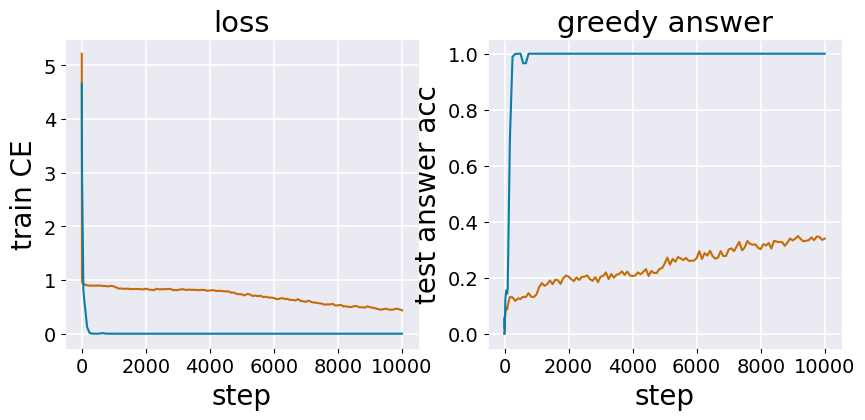

In [8]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for mode, color in (("outcome", "#c56b08"), ("process", "#087eaa")):
    h = history[history["mode"] == mode].sort_values("step")
    ax[0].plot(h.step, h.train_loss, color=color, label=mode)
    ax[1].plot(h.step, h.test_answer_accuracy, color=color, label=mode)
ax[0].set(xlabel="step", ylabel="train CE", title="loss")
ax[1].set(xlabel="step", ylabel="test answer acc", title="greedy answer", ylim=(-0.05, 1.05))

## 8. Whole-circuit answer matrices

Fix the gate list, vary the start over all 16 states. Row = start, column = predicted answer. Empty row = the model never even emitted `<COLON>`.

/home/hariguru/miniconda3/envs/ashu_env/lib/python3.11/site-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(


fixed outcome shape (16, 16) row-sum mean 1.0
learned outcome shape (16, 16) row-sum mean 1.0
learned process shape (16, 16) row-sum mean 1.0


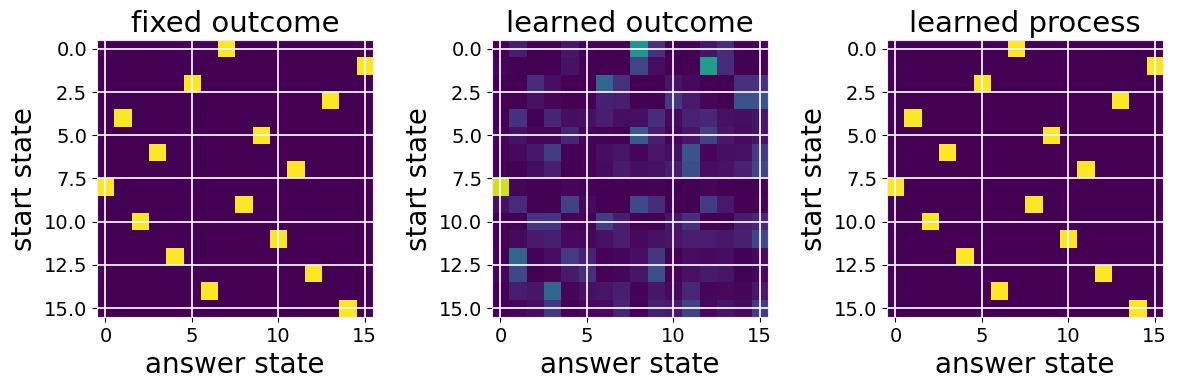

In [9]:
from handcoded.eval import circuit_answer_matrix

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
mats = {
    "fixed outcome": circuit_answer_matrix(fixed_o, circuit_prompts, tok, "outcome"),
    "learned outcome": circuit_answer_matrix(models["outcome"], circuit_prompts, tok, "outcome"),
    "learned process": circuit_answer_matrix(models["process"], circuit_prompts, tok, "process"),
}
for a, (title, mat) in zip(axes, mats.items()):
    a.imshow(mat, vmin=0, vmax=1, cmap="viridis")
    a.set_title(title)
    a.set_xlabel("answer state")
    a.set_ylabel("start state")
    print(title, "shape", mat.shape, "row-sum mean", float(np.asarray(mat).sum(-1).mean().round(3)))
fig.tight_layout()

## 9. Residual stream of the *fixed* outcome model

One block per gate. We hook the hidden state after each block — cumulative execution, not attention pretty-pictures.

gates ['x0', 'c01', 't012', 's03'] n_layers 4 layer0 (16, 16)


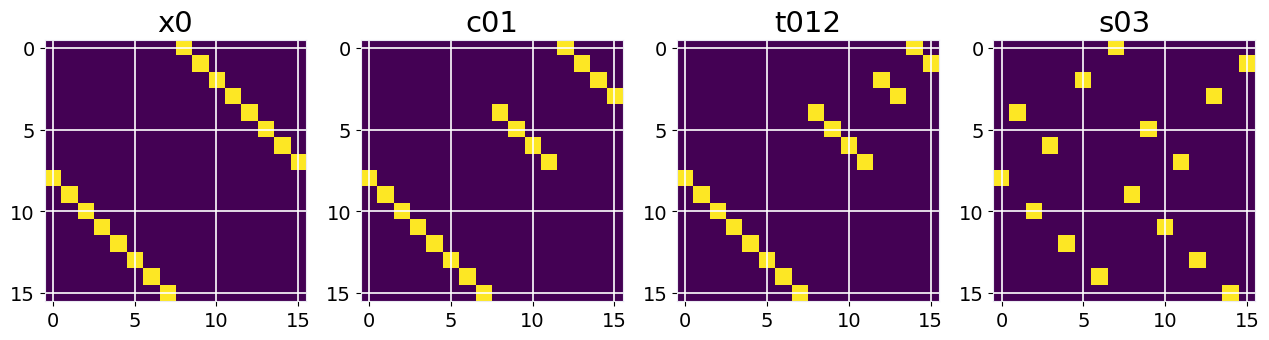

In [10]:
from handcoded.eval import inspect_fixed_circuit

snap = inspect_fixed_circuit(fixed_o, ANIMATION_GATES, tok, device)
print("gates", snap["gates"], "n_layers", len(snap["layers"]), "layer0", snap["layers"][0].shape)
fig, axes = plt.subplots(1, len(snap["layers"]), figsize=(3.2 * len(snap["layers"]), 3.2))
for a, gate, layer in zip(axes, snap["gates"], snap["layers"]):
    a.imshow(layer, cmap="viridis")
    a.set_title(gate)
fig.tight_layout()

## 10. Training dynamics

Same heatmaps over checkpoints. Frames are **measured** steps. Uncomment the first export for the training MP4. The second clip walks **every test circuit** (gold vs learned outcome vs process) with a shared legend.

In [13]:
import importlib
import handcoded.eval
import handcoded.animate

importlib.reload(handcoded.eval)
importlib.reload(handcoded.animate)

from handcoded.animate import (
    animate_all_circuits, animate_training_dynamics, export_training_animation, save_training_mp4,
)
from handcoded.eval import free_run_metrics

fixed_metrics = {
    "train_loss": language_model_loss(fixed_o, test_data["outcome"].select(slice(0, 32))).item(),
    "train_answer_accuracy_sample": free_run_metrics(fixed_o, train_eval, tok, "outcome")["final_answer"],
    "test_answer_accuracy": free_run_metrics(fixed_o, test_eval, tok, "outcome")["final_answer"],
    "test_exact_continuation": free_run_metrics(fixed_o, test_eval, tok, "outcome")["exact_continuation"],
}
anim = animate_training_dynamics(history, snap, fixed_metrics, interval_ms=140, dpi=80 if SMOKE else 140)
print(type(anim))
# from IPython.display import display
# display(export_training_animation(anim))
save_training_mp4(anim, str(ROOT / "docs/assets/training_dynamics.mp4"))

catalog = animate_all_circuits(test, models, tok, device, interval_ms=220, dpi=80 if SMOKE else 120)
print("catalog frames", len(test))
save_training_mp4(catalog, str(ROOT / "docs/assets/all_circuits.mp4"), fps=4, dpi=140 if SMOKE else 180)

<class 'matplotlib.animation.FuncAnimation'>
Saved MP4: /home/hariguru/aayus/trace/docs/assets/training_dynamics.mp4


circuit matrices:   0%|          | 0/999 [00:00<?, ?it/s]

/home/hariguru/miniconda3/envs/ashu_env/lib/python3.11/site-packages/torch/nn/modules/activation.py:1160: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at ../aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(


catalog frames 1000
Saved MP4: /home/hariguru/aayus/trace/docs/assets/all_circuits.mp4


PosixPath('/home/hariguru/aayus/trace/docs/assets/all_circuits.mp4')